## Load CSVs

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import defaultdict
from tqdm import tqdm

# Set display options
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

print("Loading data files...")

# Load all CSV files
album_df = pd.read_csv('Assets/CSV/album_data.csv')
artist_df = pd.read_csv('Assets/CSV/artist_data.csv')
genre_df = pd.read_csv('Assets/CSV/genre_data.csv')
track_df = pd.read_csv('Assets/CSV/track_data.csv')
train_df = pd.read_csv('Assets/CSV/train_data.csv')
test_df = pd.read_csv('Assets/CSV/test_data.csv')

print(f"Albums: {len(album_df):,} rows")
print(f"Artists: {len(artist_df):,} rows")
print(f"Genres: {len(genre_df):,} rows")
print(f"Tracks: {len(track_df):,} rows")
print(f"Training ratings: {len(train_df):,} rows")
print(f"Test items: {len(test_df):,} rows")
print(f"Test users: {test_df['UserID'].nunique():,}")

Loading data files...
Albums: 52,829 rows
Artists: 18,674 rows
Genres: 567 rows
Tracks: 224,041 rows
Training ratings: 12,403,575 rows
Test items: 120,000 rows
Test users: 20,000


## Create Visualizations

TRACK DATA SAMPLE (showing hierarchy)
   TrackID   AlbumID  ArtistID    Genre1    Genre2    Genre3    Genre4  \
0        1  106710.0  281667.0  214765.0  162234.0  155788.0       NaN   
1        2  280977.0  233685.0  131552.0  173467.0   48505.0       NaN   
2        3   38422.0  219136.0   61215.0  201738.0   88853.0       NaN   
3        4  119529.0  166863.0   17453.0   35389.0       NaN       NaN   
4        5   16742.0  294690.0   61215.0   34486.0  274088.0       NaN   
5        7  101746.0   44649.0  198263.0       NaN       NaN       NaN   
6        8   58498.0  142773.0  274161.0   61215.0  274088.0  163949.0   
7        9       NaN       NaN   61215.0   34486.0  274088.0       NaN   
8       10   88722.0  179846.0  186413.0   77904.0       NaN       NaN   
9       11   54548.0  206862.0   98154.0   48505.0       NaN       NaN   

   Genre5  Genre6  Genre7  Genre8  Genre9  Genre10  Genre11  Genre12  Genre13  \
0     NaN     NaN     NaN     NaN     NaN      NaN      NaN      N

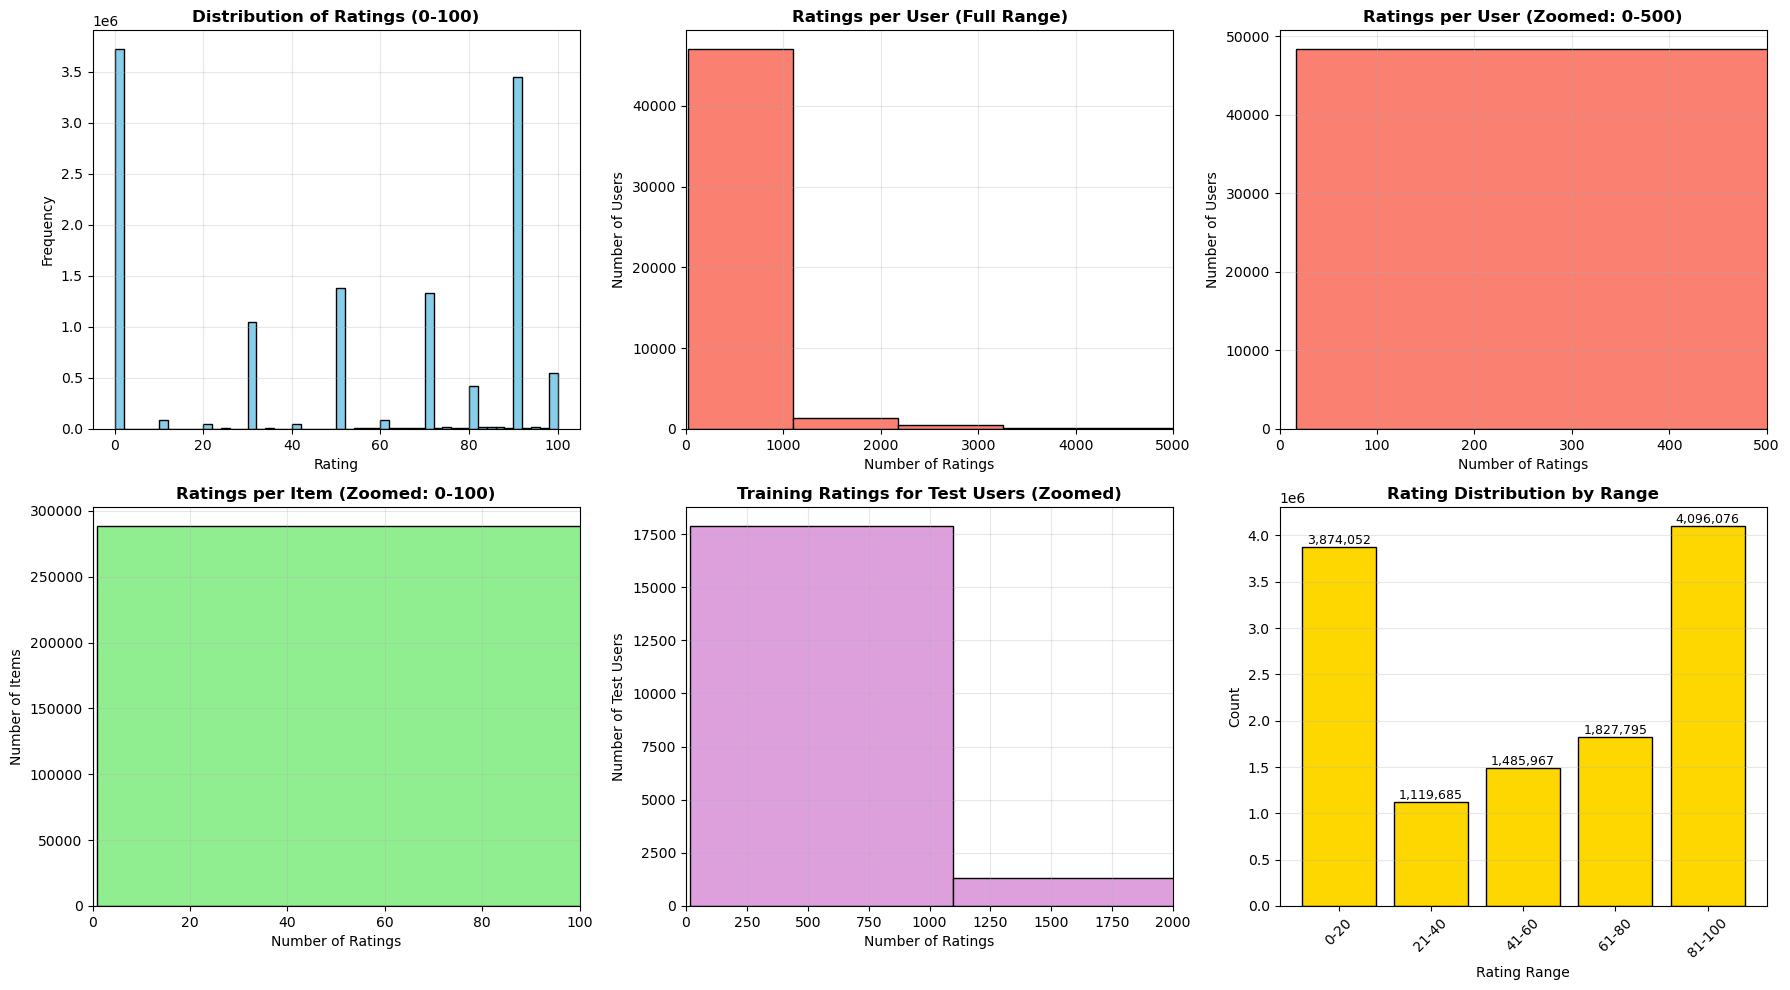


RATING STATISTICS
Rating Statistics:
  Mean: 49.77
  Median: 50.00
  Std Dev: 38.03
  Min: 0
  Max: 100

User Rating Statistics:
  Mean ratings per user: 252.1
  Median ratings per user: 61.0
  Max ratings by a user: 107,936
  Users with >1000 ratings: 2,446

Item Rating Statistics:
  Mean ratings per item: 41.9
  Median ratings per item: 10.0
  Max ratings for an item: 23,364
  Items with >50 ratings: 36,826

Test User Statistics:
  Test users: 20,000
  Mean training ratings: 532.2
  Median training ratings: 211.0
  Test users with <10 ratings: 0


In [2]:
# Explore the data structure
print("TRACK DATA SAMPLE (showing hierarchy)")
print(track_df.head(10))

print("\n")
print("TRAINING DATA SAMPLE (user ratings)")
print(train_df.head(10))

print("\n")
print("TEST DATA SAMPLE (tracks to predict)")
print(test_df.head(12))

# Visualize data statistics with better zoom
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# 1. Rating distribution
axes[0, 0].hist(train_df['Rating'], bins=50, color='skyblue', edgecolor='black')
axes[0, 0].set_title('Distribution of Ratings (0-100)', fontsize=12, weight='bold')
axes[0, 0].set_xlabel('Rating')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].grid(alpha=0.3)

# 2. Ratings per user (ZOOMED)
user_rating_counts = train_df.groupby('UserID').size()
axes[0, 1].hist(user_rating_counts, bins=100, color='salmon', edgecolor='black')
axes[0, 1].set_title('Ratings per User (Full Range)', fontsize=12, weight='bold')
axes[0, 1].set_xlabel('Number of Ratings')
axes[0, 1].set_ylabel('Number of Users')
axes[0, 1].set_xlim(0, 5000)  # Zoom to see detail
axes[0, 1].grid(alpha=0.3)

# 2b. Ratings per user (EXTREME ZOOM)
axes[0, 2].hist(user_rating_counts, bins=50, color='salmon', edgecolor='black')
axes[0, 2].set_title('Ratings per User (Zoomed: 0-500)', fontsize=12, weight='bold')
axes[0, 2].set_xlabel('Number of Ratings')
axes[0, 2].set_ylabel('Number of Users')
axes[0, 2].set_xlim(0, 500)  # Extreme zoom
axes[0, 2].grid(alpha=0.3)

# 3. Item rating frequency (ZOOMED)
item_rating_counts = train_df.groupby('ItemID').size()
axes[1, 0].hist(item_rating_counts, bins=100, color='lightgreen', edgecolor='black')
axes[1, 0].set_title('Ratings per Item (Zoomed: 0-100)', fontsize=12, weight='bold')
axes[1, 0].set_xlabel('Number of Ratings')
axes[1, 0].set_ylabel('Number of Items')
axes[1, 0].set_xlim(0, 100)  # Zoom to see the distribution
axes[1, 0].grid(alpha=0.3)

# 4. Test users per rating count (ZOOMED)
test_users = test_df['UserID'].unique()
test_user_rating_counts = train_df[train_df['UserID'].isin(test_users)].groupby('UserID').size()
axes[1, 1].hist(test_user_rating_counts, bins=100, color='plum', edgecolor='black')
axes[1, 1].set_title('Training Ratings for Test Users (Zoomed)', fontsize=12, weight='bold')
axes[1, 1].set_xlabel('Number of Ratings')
axes[1, 1].set_ylabel('Number of Test Users')
axes[1, 1].set_xlim(0, 2000)  # Zoom to see distribution
axes[1, 1].grid(alpha=0.3)

# 5. Rating value breakdown (categorical view)
rating_bins = [0, 20, 40, 60, 80, 100]
rating_labels = ['0-20', '21-40', '41-60', '61-80', '81-100']
train_df['RatingBin'] = pd.cut(train_df['Rating'], bins=rating_bins, labels=rating_labels, include_lowest=True)
rating_counts = train_df['RatingBin'].value_counts().sort_index()

axes[1, 2].bar(rating_counts.index, rating_counts.values, color='gold', edgecolor='black')
axes[1, 2].set_title('Rating Distribution by Range', fontsize=12, weight='bold')
axes[1, 2].set_xlabel('Rating Range')
axes[1, 2].set_ylabel('Count')
axes[1, 2].tick_params(axis='x', rotation=45)
axes[1, 2].grid(alpha=0.3, axis='y')

# Add count labels on bars
for i, (label, count) in enumerate(zip(rating_counts.index, rating_counts.values)):
    axes[1, 2].text(i, count, f'{count:,}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

# Print detailed statistics
print(f"\n{'='*60}")
print("RATING STATISTICS")
print(f"{'='*60}")
print(f"Rating Statistics:")
print(f"  Mean: {train_df['Rating'].mean():.2f}")
print(f"  Median: {train_df['Rating'].median():.2f}")
print(f"  Std Dev: {train_df['Rating'].std():.2f}")
print(f"  Min: {train_df['Rating'].min()}")
print(f"  Max: {train_df['Rating'].max()}")

print(f"\nUser Rating Statistics:")
print(f"  Mean ratings per user: {user_rating_counts.mean():.1f}")
print(f"  Median ratings per user: {user_rating_counts.median():.1f}")
print(f"  Max ratings by a user: {user_rating_counts.max():,}")
print(f"  Users with >1000 ratings: {(user_rating_counts > 1000).sum():,}")

print(f"\nItem Rating Statistics:")
print(f"  Mean ratings per item: {item_rating_counts.mean():.1f}")
print(f"  Median ratings per item: {item_rating_counts.median():.1f}")
print(f"  Max ratings for an item: {item_rating_counts.max():,}")
print(f"  Items with >50 ratings: {(item_rating_counts > 50).sum():,}")

print(f"\nTest User Statistics:")
print(f"  Test users: {len(test_user_rating_counts):,}")
print(f"  Mean training ratings: {test_user_rating_counts.mean():.1f}")
print(f"  Median training ratings: {test_user_rating_counts.median():.1f}")
print(f"  Test users with <10 ratings: {(test_user_rating_counts < 10).sum():,}")

Top-Left (Rating Distribution): Shows they give mostly 0-10 or 90-100 ratings. This suggests strong likes/dislikes.

Top-Middle & Top-Right (User Activity): Most users rate very few items (<100), but some users rate thousands.

Bottom-Left (Item Popularity): Most items get very few ratings (< 10), meaning most songs/albums/artists are niche. Only a small fraction are popular.

Bottom-Middle (Test Users): Test users also have weird historis, so its likely prof gave us 1 test case per some user subset

Bottom-Right (Rating Ranges): Shows which rating values are most common

## Create Heirchy Mappings

In [3]:
print("Building track hierarchy lookup...")

# Create track to hierarchy mapping
# TrackID -> (AlbumID, ArtistID, [GenreIDs])
track_to_hierarchy = {}

for _, row in tqdm(track_df.iterrows(), total=len(track_df), desc="Processing tracks"):
    track_id = str(int(row['TrackID']))  # Convert to int first, then string
    album_id = str(int(row['AlbumID'])) if pd.notna(row['AlbumID']) else None
    artist_id = str(int(row['ArtistID'])) if pd.notna(row['ArtistID']) else None
    
    # Collect all genre columns that have values
    genre_ids = []
    for col in track_df.columns:
        if col.startswith('Genre') and pd.notna(row[col]):
            genre_ids.append(str(int(row[col])))
    
    track_to_hierarchy[track_id] = {
        'album': album_id,
        'artist': artist_id,
        'genres': genre_ids
    }

print(f"Created hierarchy for {len(track_to_hierarchy):,} tracks")

Building track hierarchy lookup...


Processing tracks:   0%|          | 0/224041 [00:00<?, ?it/s]

Processing tracks: 100%|██████████| 224041/224041 [00:32<00:00, 6872.64it/s]

Created hierarchy for 224,041 tracks


In [4]:
# Show example
example_track = '20'
if example_track in track_to_hierarchy:
    print(f"\nExample - Track {example_track}:")
    print(f"  Album: {track_to_hierarchy[example_track]['album']}")
    print(f"  Artist: {track_to_hierarchy[example_track]['artist']}")
    print(f"  Genres: {track_to_hierarchy[example_track]['genres']}")
else:
    print(f"\nTrack {example_track} not found. Available track IDs (first 5): {list(track_to_hierarchy.keys())[:5]}")


Example - Track 20:
  Album: 208724
  Artist: 96989
  Genres: ['33204', '162673', '101667']


## User Rating Lookup

In [5]:
print("Building user rating lookup...")

# Create user to ratings mapping
# UserID -> {ItemID: Rating}
user_to_ratings = defaultdict(dict)

for _, row in tqdm(train_df.iterrows(), total=len(train_df), desc="Processing ratings"):
    user_id = str(row['UserID'])
    item_id = str(row['ItemID'])
    rating = row['Rating']
    
    user_to_ratings[user_id][item_id] = rating

print(f"Created rating lookup for {len(user_to_ratings):,} users")

Building user rating lookup...


Processing ratings: 100%|██████████| 12403575/12403575 [12:06<00:00, 17066.23it/s]

Created rating lookup for 49,204 users


In [6]:
# Show example
example_user = '199808'
print(f"\nExample - User {example_user}:")
print(f"  Total ratings: {len(user_to_ratings[example_user])}")
print(f"  Sample ratings: {dict(list(user_to_ratings[example_user].items())[:5])}")


Example - User 199808:
  Total ratings: 35
  Sample ratings: {'248969': 90, '2663': 90, '28341': 90, '42563': 90, '59092': 90}


## Visualize heirachy connections for a test user

In [7]:
# Visualize hierarchy for a sample test user
sample_user = str(test_df.iloc[0]['UserID'])
sample_tracks = test_df[test_df['UserID'] == int(sample_user)]['TrackID'].astype(str).tolist()

print(f"Visualizing hierarchy for User {sample_user}")
print("="*80)

viz_data = []
for track_id in sample_tracks:
    hierarchy = track_to_hierarchy.get(track_id, {})
    album_id = hierarchy.get('album')
    artist_id = hierarchy.get('artist')
    genre_ids = hierarchy.get('genres', [])
    
    # Get user ratings for these items
    user_ratings = user_to_ratings[sample_user]
    track_rating = user_ratings.get(track_id, None)
    album_rating = user_ratings.get(album_id, None) if album_id else None
    artist_rating = user_ratings.get(artist_id, None) if artist_id else None
    genre_ratings = [user_ratings.get(g, None) for g in genre_ids]
    
    viz_data.append({
        'TrackID': track_id,
        'AlbumID': album_id,
        'Album_Rating': album_rating,
        'ArtistID': artist_id,
        'Artist_Rating': artist_rating,
        'GenreIDs': ', '.join(genre_ids[:3]) if genre_ids else 'None',
        'Genre_Ratings': ', '.join([str(r) if r else '-' for r in genre_ratings[:3]])
    })

viz_df = pd.DataFrame(viz_data)
print(viz_df.to_string(index=False))

Visualizing hierarchy for User 199810
TrackID AlbumID Album_Rating ArtistID  Artist_Rating               GenreIDs Genre_Ratings
 208019  209288         None     None            NaN                   None              
  74139  277282         None   271146            NaN 113360, 173467, 173655      -, 80, -
   9903    None         None     None            NaN   33722, 123396, 79926       -, -, -
 242681  190640         None   244574            NaN   61215, 17453, 274088       -, -, -
  18515  146344         None    33168           70.0   19913, 48505, 154024       -, -, -
 105760   93458         None    11616           90.0  131552, 173467, 48505     80, 80, -


## Scoring Ruleset

In [8]:
def compute_track_score(user_id, track_id, track_to_hierarchy, user_to_ratings, 
                        weights={'album': 0.5, 'artist': 0.3, 'genre': 0.2},
                        default_rating=50):
    """    
    Args:
        user_id: User ID string
        track_id: Track ID string
        track_to_hierarchy: Dictionary mapping track IDs to hierarchy info
        user_to_ratings: Dictionary mapping user IDs to their ratings
        weights: Dictionary with weights for album, artist, genre
        default_rating: Default rating when no history exists
    
    Returns:
        score: Float score for the track
    """
    # Get hierarchy (album, artist, genres) and user ratings (album, artist, genres)
    hierarchy = track_to_hierarchy.get(track_id, {})
    user_ratings = user_to_ratings.get(user_id, {})
    
    # Extract hierarchy info
    album_id = hierarchy.get('album')
    artist_id = hierarchy.get('artist')
    genre_ids = hierarchy.get('genres', [])
    
    # Check if user has rated the album, artist, or genres
    album_rating = user_ratings.get(album_id) if album_id else None
    artist_rating = user_ratings.get(artist_id) if artist_id else None
    genre_ratings = [user_ratings.get(g) for g in genre_ids if g in user_ratings]
    

    '''
    Here we track the total score and total weight
    For example if a user rated a album:
    score += 0.5 * 70
    total_weight += 0.5

    If he has genre ratings (and in the case we have several):
    1. Average
    2. Apply weight
    3. Add to total score
    '''


    # Calculate weighted score
    score = 0
    total_weight = 0
    
    # Album score
    if album_rating is not None:
        score += weights['album'] * album_rating
        total_weight += weights['album']
    
    # Artist score
    if artist_rating is not None:
        score += weights['artist'] * artist_rating
        total_weight += weights['artist']
    
    # Genre score (average of all genre ratings)
    if genre_ratings:
        avg_genre_rating = np.mean(genre_ratings)
        score += weights['genre'] * avg_genre_rating
        total_weight += weights['genre']
    
    '''
    For the final score, we normalize it.
    In the event that maybe the user provided values for the album, but not artist, we want to reflect that effect in the score.
    '''
    # If we have some ratings, normalize by actual weight used
    if total_weight > 0:
        score = score / total_weight
    else:
        # No ratings found for any hierarchy level - use default
        score = default_rating
    
    return score


# Test the scoring function
print("Testing scoring function on sample user...")
print("="*80)

sample_user = str(test_df.iloc[0]['UserID'])
sample_tracks = test_df[test_df['UserID'] == int(sample_user)]['TrackID'].astype(str).tolist()

test_scores = []
for track_id in sample_tracks:
    score = compute_track_score(sample_user, track_id, track_to_hierarchy, user_to_ratings)
    test_scores.append({'TrackID': track_id, 'Score': score})

test_scores_df = pd.DataFrame(test_scores).sort_values('Score', ascending=False)
print(f"\nScores for User {sample_user}:")
print(test_scores_df.to_string(index=False))
print(f"\nTop 3 tracks (predict 1): {test_scores_df.head(3)['TrackID'].tolist()}")
print(f"Bottom 3 tracks (predict 0): {test_scores_df.tail(3)['TrackID'].tolist()}")

Testing scoring function on sample user...

Scores for User 199810:
TrackID  Score
 105760   86.0
  74139   80.0
  18515   70.0
 208019   50.0
 242681   50.0
   9903   50.0

Top 3 tracks (predict 1): ['105760', '74139', '18515']
Bottom 3 tracks (predict 0): ['208019', '242681', '9903']


## Predictions for all test users

In [9]:
print("Generating predictions for all test users...")
print("="*80)

predictions = []

# Group test data by user
test_grouped = test_df.groupby('UserID')

for user_id, group in tqdm(test_grouped, desc="Processing users"):
    user_id_str = str(user_id)
    track_ids = group['TrackID'].astype(str).tolist()
    
    # Score each track
    scores = []
    for track_id in track_ids:
        score = compute_track_score(user_id_str, track_id, track_to_hierarchy, user_to_ratings)
        scores.append((track_id, score))
    
    # Sort by score descending
    scores.sort(key=lambda x: x[1], reverse=True)
    
    # Top 3 get 1, bottom 3 get 0
    for i, (track_id, score) in enumerate(scores):
        predictor = 1 if i < 3 else 0
        predictions.append({
            'TrackID': f"{user_id}_{track_id}",
            'Predictor': predictor
        })

predictions_df = pd.DataFrame(predictions)

print(f"✓ Generated {len(predictions_df):,} predictions")
print(f"✓ Predictions with 1: {(predictions_df['Predictor'] == 1).sum():,}")
print(f"✓ Predictions with 0: {(predictions_df['Predictor'] == 0).sum():,}")
print("\nSample predictions:")
print(predictions_df.head(12))

Generating predictions for all test users...


Processing users: 100%|██████████| 20000/20000 [00:03<00:00, 5056.99it/s]


✓ Generated 120,000 predictions
✓ Predictions with 1: 60,000
✓ Predictions with 0: 60,000

Sample predictions:
          TrackID  Predictor
0   199810_105760          1
1    199810_74139          1
2    199810_18515          1
3   199810_208019          0
4     199810_9903          0
5   199810_242681          0
6   199812_142408          1
7   199812_130023          1
8   199812_223706          1
9    199812_29189          0
10  199812_276940          0
11  199812_211361          0


## Check if 3 ones and 3 zeros

In [10]:
# Validate the submission format
print("Validating submission...")
print("="*80)

# Check counts
num_users = test_df['UserID'].nunique()
expected_predictions = num_users * 6
actual_predictions = len(predictions_df)

print(f"Expected predictions: {expected_predictions:,}")
print(f"Actual predictions: {actual_predictions:,}")
print(f"Match: {'✓' if expected_predictions == actual_predictions else '✗'}")

# Extract UserID from TrackID column for faster grouping
predictions_df['UserID_extracted'] = predictions_df['TrackID'].str.split('_').str[0].astype(int)

# Group by user and validate - MUCH FASTER
user_validation = predictions_df.groupby('UserID_extracted')['Predictor'].agg(['sum', 'count'])
user_validation.columns = ['num_ones', 'total']
user_validation['num_zeros'] = user_validation['total'] - user_validation['num_ones']

# Check for errors
invalid_users = user_validation[(user_validation['num_ones'] != 3) | (user_validation['num_zeros'] != 3)]

validation_errors = len(invalid_users)

if validation_errors == 0:
    print("✓ All users have exactly 3 ones and 3 zeros")
else:
    print(f"✗ {validation_errors} users have incorrect prediction counts")
    print("\nFirst 5 errors:")
    print(invalid_users.head())

# Drop the temporary column before saving
predictions_df = predictions_df.drop('UserID_extracted', axis=1)

# Save submission file
output_file = 'submission.csv'
predictions_df.to_csv(output_file, index=False)
print(f"\n✓ Submission saved to: {output_file}")

# Display summary statistics
print("\n")
print("SUBMISSION SUMMARY")
print(f"Total users: {num_users:,}")
print(f"Total predictions: {len(predictions_df):,}")
print(f"Recommendations (1): {(predictions_df['Predictor'] == 1).sum():,} ({(predictions_df['Predictor'] == 1).sum()/len(predictions_df)*100:.1f}%)")
print(f"Non-recommendations (0): {(predictions_df['Predictor'] == 0).sum():,} ({(predictions_df['Predictor'] == 0).sum()/len(predictions_df)*100:.1f}%)")

Validating submission...
Expected predictions: 120,000
Actual predictions: 120,000
Match: ✓
✓ All users have exactly 3 ones and 3 zeros

✓ Submission saved to: submission.csv


SUBMISSION SUMMARY
Total users: 20,000
Total predictions: 120,000
Recommendations (1): 60,000 (50.0%)
Non-recommendations (0): 60,000 (50.0%)


## Rule Performance

Analyzing rating coverage...


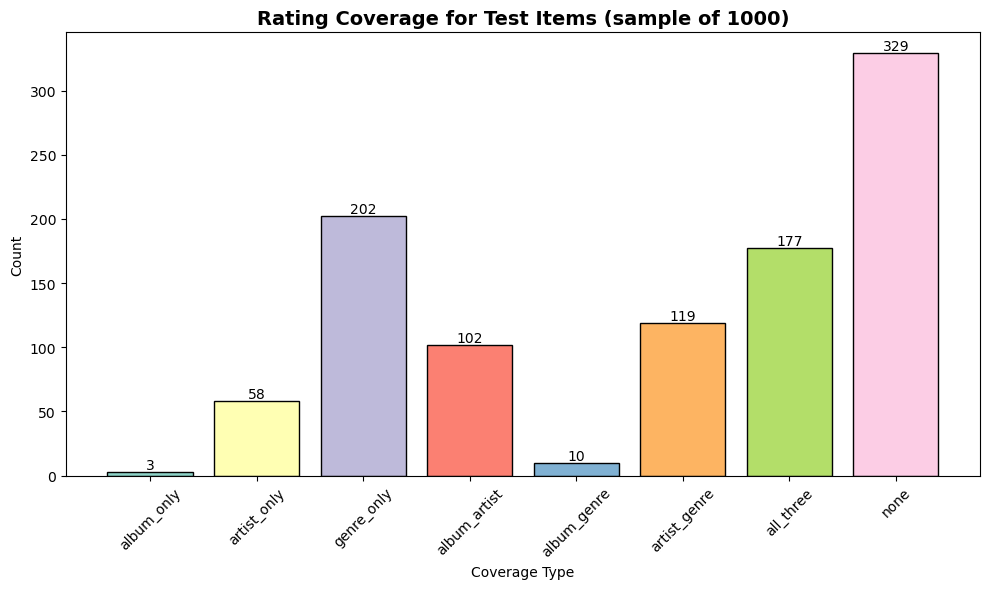


Coverage Statistics:
  album_only: 3 (0.3%)
  artist_only: 58 (5.8%)
  genre_only: 202 (20.2%)
  album_artist: 102 (10.2%)
  album_genre: 10 (1.0%)
  artist_genre: 119 (11.9%)
  all_three: 177 (17.7%)
  none: 329 (32.9%)


In [11]:
# Analyze what kinds of ratings are being used
print("Analyzing rating coverage...")
print("="*80)

coverage_stats = {
    'album_only': 0,
    'artist_only': 0,
    'genre_only': 0,
    'album_artist': 0,
    'album_genre': 0,
    'artist_genre': 0,
    'all_three': 0,
    'none': 0
}

sample_size = min(1000, len(test_df))
for _, row in test_df.head(sample_size).iterrows():
    user_id = str(row['UserID'])
    track_id = str(row['TrackID'])
    
    hierarchy = track_to_hierarchy.get(track_id, {})
    user_ratings = user_to_ratings.get(user_id, {})
    
    has_album = hierarchy.get('album') in user_ratings if hierarchy.get('album') else False
    has_artist = hierarchy.get('artist') in user_ratings if hierarchy.get('artist') else False
    has_genre = any(g in user_ratings for g in hierarchy.get('genres', []))
    
    if has_album and has_artist and has_genre:
        coverage_stats['all_three'] += 1
    elif has_album and has_artist:
        coverage_stats['album_artist'] += 1
    elif has_album and has_genre:
        coverage_stats['album_genre'] += 1
    elif has_artist and has_genre:
        coverage_stats['artist_genre'] += 1
    elif has_album:
        coverage_stats['album_only'] += 1
    elif has_artist:
        coverage_stats['artist_only'] += 1
    elif has_genre:
        coverage_stats['genre_only'] += 1
    else:
        coverage_stats['none'] += 1

# Visualize coverage
fig, ax = plt.subplots(figsize=(10, 6))
labels = list(coverage_stats.keys())
values = list(coverage_stats.values())
colors = plt.cm.Set3(range(len(labels)))

bars = ax.bar(labels, values, color=colors, edgecolor='black')
ax.set_title(f'Rating Coverage for Test Items (sample of {sample_size})', fontsize=14, weight='bold')
ax.set_xlabel('Coverage Type')
ax.set_ylabel('Count')
ax.tick_params(axis='x', rotation=45)

# Add value labels on bars
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{int(height)}',
            ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

print("\nCoverage Statistics:")
for key, value in coverage_stats.items():
    print(f"  {key}: {value} ({value/sample_size*100:.1f}%)")

From the graph its apparent, a lot of the tracks we had chosen, the user has not rated it prior, meaning that we are defaulting for a majority of the values

## NEW attempt idea

The idea is, we create a new section, that contains the average rating of each album/artist/genre, in some table, of all the ratings for that item

Then in the computation function, if the user never rated that album/artist/genre, we assign the average value for that object in our calculation

In [12]:
# Build average rating lookup tables from all training data
# Each table maps ItemID -> average rating across all users

overall_mean_rating = train_df['Rating'].mean()

item_avg_ratings = train_df.groupby('ItemID')['Rating'].mean().to_dict()

album_avg_ratings = {
    str(int(album_id)): item_avg_ratings.get(int(album_id), overall_mean_rating)
    for album_id in album_df['AlbumID'].dropna().unique()
}

artist_avg_ratings = {
    str(int(artist_id)): item_avg_ratings.get(int(artist_id), overall_mean_rating)
    for artist_id in artist_df['ArtistID'].dropna().unique()
}

genre_avg_ratings = {
    str(int(genre_id)): item_avg_ratings.get(int(genre_id), overall_mean_rating)
    for genre_id in genre_df['GenreID'].dropna().unique()
}


def compute_track_score(
    user_id,
    track_id,
    track_to_hierarchy,
    user_to_ratings,
    album_avg_ratings,
    artist_avg_ratings,
    genre_avg_ratings,
    weights={'album': 0.5, 'artist': 0.3, 'genre': 0.2},
    default_rating=50
):
    """
    Compute a track score using:
    - the user's own rating if it exists
    - otherwise the global average rating for that album/artist/genre
    - otherwise the default rating
    """

    # Get hierarchy info for this track
    hierarchy = track_to_hierarchy.get(track_id, {})
    user_ratings = user_to_ratings.get(user_id, {})

    album_id = hierarchy.get('album')
    artist_id = hierarchy.get('artist')
    genre_ids = hierarchy.get('genres', [])

    # Album: use user rating first, otherwise album average
    if album_id:
        album_rating = user_ratings.get(album_id, album_avg_ratings.get(album_id, default_rating))
    else:
        album_rating = None

    # Artist: use user rating first, otherwise artist average
    if artist_id:
        artist_rating = user_ratings.get(artist_id, artist_avg_ratings.get(artist_id, default_rating))
    else:
        artist_rating = None

    # Genres: for each genre, use user rating if available, otherwise global genre average
    genre_ratings = []
    for genre_id in genre_ids:
        if genre_id in user_ratings:
            genre_ratings.append(user_ratings[genre_id])
        else:
            genre_ratings.append(genre_avg_ratings.get(genre_id, default_rating))

    # Weighted score
    score = 0
    total_weight = 0

    if album_rating is not None:
        score += weights['album'] * album_rating
        total_weight += weights['album']

    if artist_rating is not None:
        score += weights['artist'] * artist_rating
        total_weight += weights['artist']

    if genre_ratings:
        avg_genre_rating = np.mean(genre_ratings)
        score += weights['genre'] * avg_genre_rating
        total_weight += weights['genre']

    if total_weight > 0:
        score = score / total_weight
    else:
        score = default_rating

    return score


In [13]:
print("Generating predictions for all test users...")
print("="*80)

predictions = []

# Group test data by user
test_grouped = test_df.groupby('UserID')

for user_id, group in tqdm(test_grouped, desc="Processing users"):
    user_id_str = str(user_id)
    track_ids = group['TrackID'].astype(str).tolist()
    
    # Score each track
    scores = []
    for track_id in track_ids:
        score = compute_track_score(user_id_str, track_id, track_to_hierarchy, user_to_ratings, album_avg_ratings, artist_avg_ratings, genre_avg_ratings)
        scores.append((track_id, score))
    
    # Sort by score descending
    scores.sort(key=lambda x: x[1], reverse=True)
    
    # Top 3 get 1, bottom 3 get 0
    for i, (track_id, score) in enumerate(scores):
        predictor = 1 if i < 3 else 0
        predictions.append({
            'TrackID': f"{user_id}_{track_id}",
            'Predictor': predictor
        })

predictions_df = pd.DataFrame(predictions)

print(f"✓ Generated {len(predictions_df):,} predictions")
print(f"✓ Predictions with 1: {(predictions_df['Predictor'] == 1).sum():,}")
print(f"✓ Predictions with 0: {(predictions_df['Predictor'] == 0).sum():,}")
print("\nSample predictions:")
print(predictions_df.head(12))

Generating predictions for all test users...


Processing users: 100%|██████████| 20000/20000 [00:04<00:00, 4091.15it/s]


✓ Generated 120,000 predictions
✓ Predictions with 1: 60,000
✓ Predictions with 0: 60,000

Sample predictions:
          TrackID  Predictor
0   199810_105760          1
1   199810_242681          1
2    199810_74139          1
3    199810_18515          0
4   199810_208019          0
5     199810_9903          0
6   199812_142408          1
7   199812_130023          1
8   199812_223706          1
9    199812_29189          0
10  199812_211361          0
11  199812_276940          0


In [14]:
# Validate the submission format
print("Validating submission...")
print("="*80)

# Check counts
num_users = test_df['UserID'].nunique()
expected_predictions = num_users * 6
actual_predictions = len(predictions_df)

print(f"Expected predictions: {expected_predictions:,}")
print(f"Actual predictions: {actual_predictions:,}")
print(f"Match: {'✓' if expected_predictions == actual_predictions else '✗'}")

# Extract UserID from TrackID column for faster grouping
predictions_df['UserID_extracted'] = predictions_df['TrackID'].str.split('_').str[0].astype(int)

# Group by user and validate - MUCH FASTER
user_validation = predictions_df.groupby('UserID_extracted')['Predictor'].agg(['sum', 'count'])
user_validation.columns = ['num_ones', 'total']
user_validation['num_zeros'] = user_validation['total'] - user_validation['num_ones']

# Check for errors
invalid_users = user_validation[(user_validation['num_ones'] != 3) | (user_validation['num_zeros'] != 3)]

validation_errors = len(invalid_users)

if validation_errors == 0:
    print("✓ All users have exactly 3 ones and 3 zeros")
else:
    print(f"✗ {validation_errors} users have incorrect prediction counts")
    print("\nFirst 5 errors:")
    print(invalid_users.head())

# Drop the temporary column before saving
predictions_df = predictions_df.drop('UserID_extracted', axis=1)

# Save submission file
output_file = 'submission2.csv'
predictions_df.to_csv(output_file, index=False)
print(f"\n✓ Submission saved to: {output_file}")

# Display summary statistics
print("\n" + "="*80)
print("SUBMISSION SUMMARY")
print("="*80)
print(f"Total users: {num_users:,}")
print(f"Total predictions: {len(predictions_df):,}")
print(f"Recommendations (1): {(predictions_df['Predictor'] == 1).sum():,} ({(predictions_df['Predictor'] == 1).sum()/len(predictions_df)*100:.1f}%)")
print(f"Non-recommendations (0): {(predictions_df['Predictor'] == 0).sum():,} ({(predictions_df['Predictor'] == 0).sum()/len(predictions_df)*100:.1f}%)")

Validating submission...
Expected predictions: 120,000
Actual predictions: 120,000
Match: ✓
✓ All users have exactly 3 ones and 3 zeros

✓ Submission saved to: submission2.csv

SUBMISSION SUMMARY
Total users: 20,000
Total predictions: 120,000
Recommendations (1): 60,000 (50.0%)
Non-recommendations (0): 60,000 (50.0%)


This resulted in a slightly lower score on kaggle than the previous attempt. I believe this to be due to most/many individuals may rank an object highly, while a small subset may not, which we would then relate that item to them even if the type does not match their actual preferences.

## NEW Attempt

In [15]:
from collections import defaultdict
from tqdm import tqdm

HIGH_RATING_THRESHOLD = 80

print("Building liked-track lookups...")

valid_track_ids_int = set(int(x) for x in track_to_hierarchy.keys())

liked_tracks_by_user = defaultdict(set)
track_liked_by_users = defaultdict(set)

# Filter first in pandas
filtered_train = train_df[
    (train_df['Rating'] >= HIGH_RATING_THRESHOLD) &
    (train_df['ItemID'].isin(valid_track_ids_int))
][['UserID', 'ItemID']]

# Iterate over numpy rows instead of iterrows()
for user_id, item_id in tqdm(
    filtered_train[['UserID', 'ItemID']].to_numpy(),
    total=len(filtered_train),
    desc="Processing filtered high-rated tracks"
):
    user_id = str(int(user_id))
    item_id = str(int(item_id))

    liked_tracks_by_user[user_id].add(item_id)
    track_liked_by_users[item_id].add(user_id)

print(f"Users with liked tracks: {len(liked_tracks_by_user):,}")
print(f"Tracks liked by at least one user: {len(track_liked_by_users):,}")


# --------------------------------------------------
# 2. User similarity using Jaccard overlap
# --------------------------------------------------
def jaccard_similarity(set_a, set_b):
    if not set_a and not set_b:
        return 0.0
    intersection = len(set_a & set_b)
    union = len(set_a | set_b)
    return intersection / union if union > 0 else 0.0

# --------------------------------------------------
# 3. Find similar users for a target user
# --------------------------------------------------
def get_similar_users(target_user_id, liked_tracks_by_user, track_liked_by_users, top_k=20):
    target_likes = liked_tracks_by_user.get(target_user_id, set())

    # candidate neighbors = users who share at least one liked track
    candidate_users = set()
    for track_id in target_likes:
        candidate_users.update(track_liked_by_users.get(track_id, set()))

    candidate_users.discard(target_user_id)

    similarities = []
    for other_user_id in candidate_users:
        other_likes = liked_tracks_by_user.get(other_user_id, set())
        sim = jaccard_similarity(target_likes, other_likes)
        if sim > 0:
            similarities.append((other_user_id, sim))

    similarities.sort(key=lambda x: x[1], reverse=True)
    return similarities[:top_k]

# --------------------------------------------------
# 4. Predict score for one candidate track
# --------------------------------------------------
def compute_user_user_score(user_id, track_id, user_to_ratings, liked_tracks_by_user, track_liked_by_users,
                            top_k=20, default_rating=50):
    neighbors = get_similar_users(user_id, liked_tracks_by_user, track_liked_by_users, top_k=top_k)

    numerator = 0.0
    denominator = 0.0

    for neighbor_id, sim in neighbors:
        neighbor_ratings = user_to_ratings.get(neighbor_id, {})
        if track_id in neighbor_ratings:
            numerator += sim * neighbor_ratings[track_id]
            denominator += sim

    if denominator > 0:
        return numerator / denominator
    else:
        return default_rating


Building liked-track lookups...


Processing filtered high-rated tracks: 100%|██████████| 1818070/1818070 [00:06<00:00, 272614.40it/s]


Users with liked tracks: 31,071
Tracks liked by at least one user: 197,678


In [16]:
from collections import defaultdict, Counter
from tqdm import tqdm
import pandas as pd

DEFAULT_RATING = 50
TOP_K_NEIGHBORS = 20

# --------------------------------------------------
# 1. Keep only ratings for test tracks
#    This makes neighbor scoring much lighter
# --------------------------------------------------
print("Filtering user ratings down to test tracks...")

test_track_ids = set(test_df['TrackID'].astype(str).unique())

filtered_user_ratings = {}
for user_id, ratings in tqdm(user_to_ratings.items(), total=len(user_to_ratings), desc="Filtering ratings"):
    filtered_user_ratings[user_id] = {
        item_id: rating
        for item_id, rating in ratings.items()
        if item_id in test_track_ids
    }

# --------------------------------------------------
# 2. Faster neighbor search
#    Count shared liked tracks first, then compute Jaccard
# --------------------------------------------------
def get_similar_users_fast(target_user_id, liked_tracks_by_user, track_liked_by_users, top_k=20):
    target_likes = liked_tracks_by_user.get(target_user_id, set())

    if not target_likes:
        return []

    shared_counts = Counter()

    # Count how many liked tracks each other user shares with target
    for track_id in target_likes:
        for other_user_id in track_liked_by_users.get(track_id, set()):
            if other_user_id != target_user_id:
                shared_counts[other_user_id] += 1

    target_size = len(target_likes)
    similarities = []

    for other_user_id, intersection in shared_counts.items():
        other_size = len(liked_tracks_by_user.get(other_user_id, set()))
        union = target_size + other_size - intersection

        if union > 0:
            sim = intersection / union
            if sim > 0:
                similarities.append((other_user_id, sim))

    similarities.sort(key=lambda x: x[1], reverse=True)
    return similarities[:top_k]

# --------------------------------------------------
# 3. Score one track from cached neighbors
# --------------------------------------------------
def compute_track_score_from_neighbors(track_id, neighbors, filtered_user_ratings, default_rating=50):
    numerator = 0.0
    denominator = 0.0

    for neighbor_id, sim in neighbors:
        rating = filtered_user_ratings.get(neighbor_id, {}).get(track_id)
        if rating is not None:
            numerator += sim * rating
            denominator += sim

    if denominator > 0:
        return numerator / denominator

    return default_rating

# --------------------------------------------------
# 4. Precompute neighbors once for each test user
# --------------------------------------------------
print("\nCaching neighbors for test users...")

test_user_ids = test_df['UserID'].astype(str).unique().tolist()
neighbor_cache = {}

for user_id in tqdm(test_user_ids, total=len(test_user_ids), desc="Caching neighbors"):
    neighbor_cache[user_id] = get_similar_users_fast(
        user_id,
        liked_tracks_by_user,
        track_liked_by_users,
        top_k=TOP_K_NEIGHBORS
    )

# --------------------------------------------------
# 5. Generate predictions with progress bar
# --------------------------------------------------
print("\nGenerating predictions for all test users...")
print("=" * 80)

predictions = []
test_grouped = test_df.groupby('UserID')

for user_id, group in tqdm(test_grouped, total=test_df['UserID'].nunique(), desc="Scoring test users"):
    user_id_str = str(user_id)
    candidate_tracks = group['TrackID'].astype(str).tolist()
    neighbors = neighbor_cache.get(user_id_str, [])

    scored_tracks = []
    for track_id in candidate_tracks:
        score = compute_track_score_from_neighbors(
            track_id,
            neighbors,
            filtered_user_ratings,
            default_rating=DEFAULT_RATING
        )
        scored_tracks.append((track_id, score))

    scored_tracks.sort(key=lambda x: x[1], reverse=True)

    for i, (track_id, score) in enumerate(scored_tracks):
        predictions.append({
            'TrackID': f"{user_id}_{track_id}",
            'Predictor': 1 if i < 3 else 0
        })

predictions_df = pd.DataFrame(predictions)

print(f"Generated {len(predictions_df):,} predictions")
print(f"Predictions with 1: {(predictions_df['Predictor'] == 1).sum():,}")
print(f"Predictions with 0: {(predictions_df['Predictor'] == 0).sum():,}")

print("\nSample predictions:")
print(predictions_df.head(12).to_string(index=False))

# --------------------------------------------------
# 6. Validate
# --------------------------------------------------
print("\nValidating submission...")
print("=" * 80)

num_users = test_df['UserID'].nunique()
expected_predictions = num_users * 6
actual_predictions = len(predictions_df)

print(f"Expected predictions: {expected_predictions:,}")
print(f"Actual predictions: {actual_predictions:,}")

predictions_df['UserID_extracted'] = predictions_df['TrackID'].str.split('_').str[0].astype(int)

user_validation = predictions_df.groupby('UserID_extracted')['Predictor'].agg(['sum', 'count'])
user_validation.columns = ['num_ones', 'total']
user_validation['num_zeros'] = user_validation['total'] - user_validation['num_ones']

invalid_users = user_validation[
    (user_validation['num_ones'] != 3) |
    (user_validation['num_zeros'] != 3)
]

if len(invalid_users) == 0:
    print("All users have exactly 3 ones and 3 zeros")
else:
    print(f"{len(invalid_users)} users failed validation")
    print(invalid_users.head())

predictions_df = predictions_df.drop(columns=['UserID_extracted'])

# --------------------------------------------------
# 7. Save CSV
# --------------------------------------------------
output_file = "submission_user_user_cf_fast.csv"
predictions_df.to_csv(output_file, index=False)

print(f"\nSaved submission to: {output_file}")
print("\nFirst 10 rows:")
print(predictions_df.head(10).to_string(index=False))


Filtering user ratings down to test tracks...


Filtering ratings: 100%|██████████| 49204/49204 [00:02<00:00, 21954.68it/s]



Caching neighbors for test users...


Caching neighbors: 100%|██████████| 20000/20000 [02:46<00:00, 120.18it/s]



Generating predictions for all test users...


Scoring test users: 100%|██████████| 20000/20000 [00:03<00:00, 5518.39it/s]


Generated 120,000 predictions
Predictions with 1: 60,000
Predictions with 0: 60,000

Sample predictions:
      TrackID  Predictor
199810_208019          1
 199810_74139          1
  199810_9903          1
199810_242681          0
 199810_18515          0
199810_105760          0
199812_130023          1
199812_276940          1
199812_142408          1
199812_223706          0
199812_211361          0
 199812_29189          0

Validating submission...
Expected predictions: 120,000
Actual predictions: 120,000
All users have exactly 3 ones and 3 zeros

Saved submission to: submission_user_user_cf_fast.csv

First 10 rows:
      TrackID  Predictor
199810_208019          1
 199810_74139          1
  199810_9903          1
199810_242681          0
 199810_18515          0
199810_105760          0
199812_130023          1
199812_276940          1
199812_142408          1
199812_223706          0
